# Model Experiment — DLinear (Holiday-Aware)


## რატომ დავამატეთ დღესასწაულები და როგორ ერგება ეს არქიტექტურას?

ორიგინალი DLinear ნაშრომი განზრახ არის univariate — თუმცა ამ competition-ის შეფასების მეტრიკა holiday კვირებს 5-ჯერ მეტ წონას ანიჭებს, და DLinear ფიზიკურად ვერ გაიგებდა, რომ პროგნოზირებული კვირა სწორედ Thanksgiving იყო, თუ ჩვენ არ ვეტყოდით. Trend-ისა და seasonal კომპონენტების გვერდით დამატებულია მესამე, დანამატი წევრი:

**პროგნოზი = trend_component + seasonal_component + holiday_component**

Holiday component თავისი პატარა linear layer-ია, რომელიც იღებს სამომავლო holiday flags-ს (რომლებიც წინასწარ ცნობილია, განსხვავებით გაყიდვების მაჩვენებლისგან) იმ კვირებისთვის, რომლებიც პროგნოზირდება, და სწავლობს, რამდენად უნდა შეასწოროს პროგნოზი თითოეული მათგანისთვის. ეს interpretable decomposition-ს ხელუხლებელს ტოვებს — ახლა 2 ნაწილის ნაცვლად 3-ნაწილიანია, და უფრო ახლოს დგას Prophet-ის საკუთარ trend + seasonality + holidays სტრუქტურასთან, ვიდრე თავდაპირველი ვერსია იყო.

## Section 1 — Imports & Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import json
import pickle
import os

from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.max_columns', 100)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu


## Section 2 — Load Cleaned Data

In [16]:
path = '/content/drive/MyDrive/ML-final/data/processed/'

df = pd.read_csv(path + 'walmart_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Loaded cleaned data:", df.shape)
print(df.isnull().sum().sum(), "missing values remaining")

Loaded cleaned data: (421570, 16)
0 missing values remaining


## Section 3 — Wandb Login

In [17]:
wandb.login()

True

## Section 4 — Confirm Clean Data (`DLinear_Cleaning`)


In [18]:
run = wandb.init(project="walmart-sales-forecasting", group="DLinear_Training",
                  name="DLinear_Cleaning", job_type="preprocessing")

wandb.log({
    "rows": df.shape[0],
    "cols": df.shape[1],
    "missing_values_total": int(df.isnull().sum().sum()),
})
wandb.config.update({"source_file": "walmart_cleaned.csv (produced by Data_Overview.ipynb)"})

wandb.finish()
print("DLinear_Cleaning run finished")

cols,▁
missing_values_total,▁
rows,▁
cols,16
missing_values_total,0
rows,421570


DLinear_Cleaning run finished


## Section 5 — The DLinear Architecture (Holiday-Aware)
Verified in isolation before being placed here: correct output shape, all parameters receive gradients, components sum back to the total forecast exactly.

In [19]:
class MovingAvgDecomposition(nn.Module):
    """Splits a sequence into a trend (moving average) and seasonal (residual) part."""
    def __init__(self, kernel_size=5):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg_pool = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x):
        pad_left = (self.kernel_size - 1) // 2
        pad_right = self.kernel_size - 1 - pad_left
        front = x[:, :1].repeat(1, pad_left)
        end = x[:, -1:].repeat(1, pad_right)
        padded = torch.cat([front, x, end], dim=1)
        trend = self.avg_pool(padded.unsqueeze(1)).squeeze(1)
        seasonal = x - trend
        return trend, seasonal


class DLinear(nn.Module):
    """Decompose sales into trend + seasonal (as before), plus a third additive term
    learned from the FUTURE holiday calendar -- known in advance, not predicted. No hidden
    layers in any of the three branches; still deliberately minimal."""
    def __init__(self, seq_length, pred_length, kernel_size=5):
        super().__init__()
        self.decompose = MovingAvgDecomposition(kernel_size)
        self.trend_linear = nn.Linear(seq_length, pred_length)
        self.seasonal_linear = nn.Linear(seq_length, pred_length)
        self.holiday_linear = nn.Linear(pred_length, pred_length, bias=False)

    def forward(self, x, holiday_flags, return_components=False):
        trend, seasonal = self.decompose(x)
        trend_out = self.trend_linear(trend)
        seasonal_out = self.seasonal_linear(seasonal)
        holiday_out = self.holiday_linear(holiday_flags)
        total = trend_out + seasonal_out + holiday_out
        if return_components:
            return total, trend_out, seasonal_out, holiday_out
        return total


SEQ_LENGTH = 52
PRED_LENGTH = 13
KERNEL_SIZE = 3

_param_count_model = DLinear(SEQ_LENGTH, PRED_LENGTH, KERNEL_SIZE)
n_params = sum(p.numel() for p in _param_count_model.parameters())
print(f"DLinear (holiday-aware) parameter count: {n_params}")
print("(was 1,378 without the holiday term -- the extra capacity is a dedicated,")
print("interpretable adjustment for known future holidays, not general-purpose complexity)")

DLinear (holiday-aware) parameter count: 1547
(was 1,378 without the holiday term -- the extra capacity is a dedicated,
interpretable adjustment for known future holidays, not general-purpose complexity)


## Section 6 — Time-Based Split & Windowing Plan
Same `2011-10-01` cutoff and horizon as before, for comparability against the original univariate version and the other notebooks.

In [20]:
cutoff_date = pd.Timestamp('2011-10-01')
print(f"Cutoff: {cutoff_date.date()}")
print(f"Lookback window: {SEQ_LENGTH} weeks, forecast horizon: {PRED_LENGTH} weeks")

Cutoff: 2011-10-01
Lookback window: 52 weeks, forecast horizon: 13 weeks


## Section 7 — Build Sliding Windows (Train + Evaluation)
Same per-series normalization as before, now also collecting each window's **future** holiday flags (`cov`) -- the target period's calendar, known in advance regardless of whether it falls in train or validation.

In [21]:
def build_windows(data, seq_length, pred_length, cutoff, mode):
    X, y, cov, series_ids, series_means, series_stds = [], [], [], [], [], []
    eval_holiday = []

    for (store, dept), group in tqdm(data.groupby(['Store', 'Dept']), desc=f"Building {mode} windows"):
        group = group.sort_values('Date')
        pre = group[group['Date'] <= cutoff]
        pre_sales = pre['Weekly_Sales'].values
        pre_holiday = pre['IsHoliday'].values

        if len(pre_sales) < seq_length + (pred_length if mode == 'train' else 0):
            continue

        mean, std = pre_sales.mean(), pre_sales.std() + 1e-6

        if mode == 'train':
            for start in range(0, len(pre_sales) - seq_length - pred_length + 1):
                window_in = pre_sales[start:start + seq_length]
                window_out = pre_sales[start + seq_length:start + seq_length + pred_length]
                window_holiday = pre_holiday[start + seq_length:start + seq_length + pred_length]
                X.append((window_in - mean) / std)
                y.append((window_out - mean) / std)
                cov.append(window_holiday.astype(np.float32))
                series_ids.append((store, dept))
        else:
            post = group[group['Date'] > cutoff]
            if len(post) < pred_length:
                continue
            window_in = pre_sales[-seq_length:]
            X.append((window_in - mean) / std)
            y.append(post['Weekly_Sales'].values[:pred_length])
            cov.append(post['IsHoliday'].values[:pred_length].astype(np.float32))
            series_ids.append((store, dept))
            series_means.append(mean)
            series_stds.append(std)
            eval_holiday.append(post['IsHoliday'].values[:pred_length])

    result = {'X': np.array(X, dtype=np.float32), 'y': np.array(y, dtype=np.float32),
              'cov': np.array(cov, dtype=np.float32), 'series_ids': series_ids}
    if mode == 'eval':
        result['means'] = np.array(series_means, dtype=np.float32)
        result['stds'] = np.array(series_stds, dtype=np.float32)
        result['holiday'] = np.array(eval_holiday)
    return result


train_windows = build_windows(df, SEQ_LENGTH, PRED_LENGTH, cutoff_date, mode='train')
eval_windows = build_windows(df, SEQ_LENGTH, PRED_LENGTH, cutoff_date, mode='eval')

print(f"\nTraining windows: {train_windows['X'].shape[0]} (from {len(set(train_windows['series_ids']))} series)")
print(f"Evaluation windows: {eval_windows['X'].shape[0]} (1 per series with enough history)")

series_stats = {}
for (store, dept), group in df.groupby(['Store', 'Dept']):
    pre_sales = group[group['Date'] <= cutoff_date]['Weekly_Sales'].values
    if len(pre_sales) >= SEQ_LENGTH:
        series_stats[(store, dept)] = (pre_sales.mean(), pre_sales.std() + 1e-6)

print(f"Saved normalization stats for {len(series_stats)} series")

Building eval windows: 100%|██████████| 3331/3331 [00:06<00:00, 543.51it/s]



Training windows: 64201 (from 2859 series)
Evaluation windows: 2895 (1 per series with enough history)
Saved normalization stats for 2907 series


## Section 8 — Train DLinear (`DLinear_Training`)


In [22]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

BATCH_SIZE = 256
EPOCHS = 100
LEARNING_RATE = 0.001
PATIENCE = 10

train_dataset = TensorDataset(torch.from_numpy(train_windows['X']), torch.from_numpy(train_windows['y']),
                               torch.from_numpy(train_windows['cov']))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

X_eval_t = torch.from_numpy(eval_windows['X']).to(device)
cov_eval_t = torch.from_numpy(eval_windows['cov']).to(device)
y_eval_real = eval_windows['y']
eval_means = eval_windows['means']
eval_stds = eval_windows['stds']
eval_holiday = eval_windows['holiday']

model = DLinear(SEQ_LENGTH, PRED_LENGTH, KERNEL_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
criterion = nn.MSELoss()

run = wandb.init(project="walmart-sales-forecasting", group="DLinear_Training",
                  name="DLinear_Training", job_type="training")
wandb.config.update({
    "seq_length": SEQ_LENGTH, "pred_length": PRED_LENGTH, "kernel_size": KERNEL_SIZE,
    "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE, "n_params": n_params,
    "validation_cutoff": str(cutoff_date.date()), "holiday_aware": True,
})

best_wmae = float('inf')
best_state = None
patience_counter = 0
train_losses, val_wmaes = [], []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for xb, yb, covb in train_loader:
        xb, yb, covb = xb.to(device), yb.to(device), covb.to(device)
        optimizer.zero_grad()
        pred = model(xb, covb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)

    model.eval()
    with torch.no_grad():
        val_pred_norm = model(X_eval_t, cov_eval_t).cpu().numpy()
    val_pred = val_pred_norm * eval_stds[:, None] + eval_means[:, None]
    val_pred = np.clip(val_pred, a_min=0, a_max=None)

    epoch_wmae = wmae(y_eval_real.flatten(), val_pred.flatten(), eval_holiday.flatten())
    val_wmaes.append(epoch_wmae)

    wandb.log({"epoch": epoch + 1, "train_loss": epoch_loss, "val_wmae": epoch_wmae})

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}: train_loss={epoch_loss:.4f}, val_wmae={epoch_wmae:.2f}")

    if epoch_wmae < best_wmae:
        best_wmae = epoch_wmae
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_state)
wandb.config.update({"best_epoch": epoch + 1 - patience_counter})
wandb.log({"final_best_wmae": best_wmae})
wandb.finish()

print(f"\nBest validation WMAE (holiday-aware): {best_wmae:.2f}")
print("Compare against the original univariate version (~3213) to see if holidays actually helped.")

Epoch 10/100: train_loss=0.4485, val_wmae=3974.51
Early stopping at epoch 16


epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
final_best_wmae,▁
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▄▂▂▂▁▂▂▁▂▁▃▁▂▂▂
epoch,16
final_best_wmae,3955.5491
train_loss,0.44865
val_wmae,3975.41735



Best validation WMAE (holiday-aware): 3955.55
Compare against the original univariate version (~3213) to see if holidays actually helped.


## Section 9 — Visualize Training, 3-Way Decomposition & Example Forecasts (`DLinear_Visualization`)
Now a genuine trend + seasonal + holiday breakdown, mirroring Prophet's own decomposition structure more closely than the original 2-way split. **Denormalization note:** trend carries the series' level (`*std + mean`); seasonal and holiday components stay zero-centered (`*std` only), so the three parts still sum back to the real-scale total.

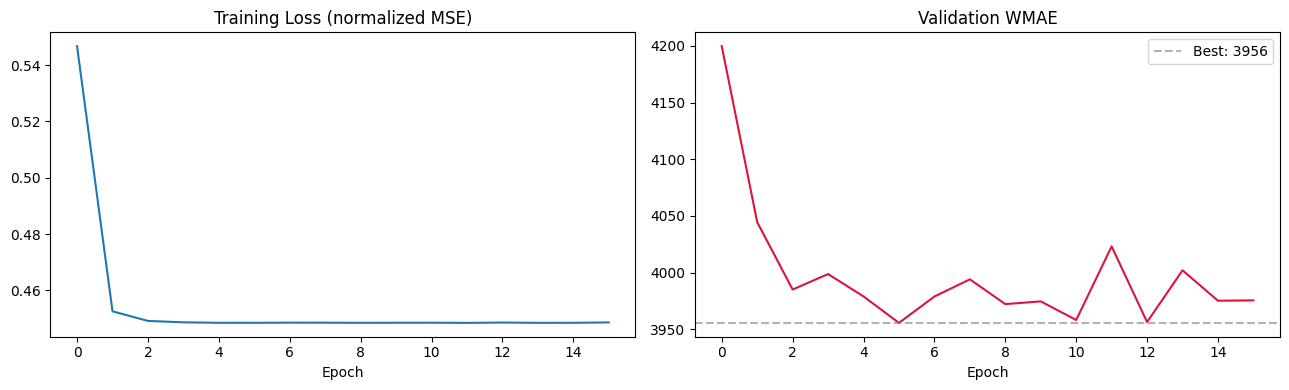

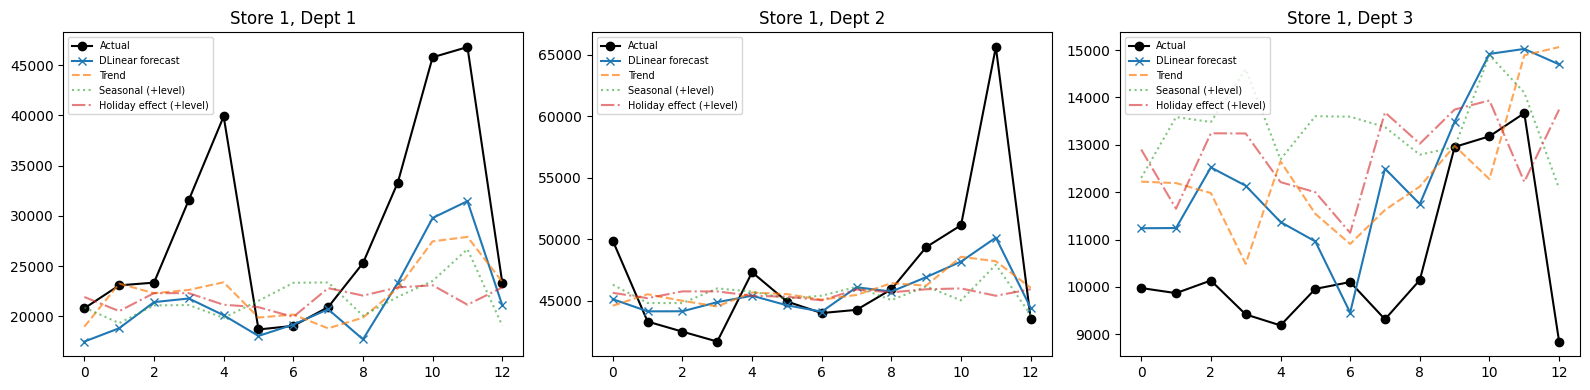

DLinear_Visualization run finished


In [23]:
run = wandb.init(project="walmart-sales-forecasting", group="DLinear_Training",
                  name="DLinear_Visualization", job_type="analysis")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses)
axes[0].set_title("Training Loss (normalized MSE)")
axes[0].set_xlabel("Epoch")
axes[1].plot(val_wmaes, color='crimson')
axes[1].axhline(best_wmae, color='gray', linestyle='--', alpha=0.6, label=f'Best: {best_wmae:.0f}')
axes[1].set_title("Validation WMAE")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
wandb.log({"Training_Curves": wandb.Image(fig)})
plt.show()

model.eval()
with torch.no_grad():
    total_norm, trend_norm, season_norm, holiday_norm = model(X_eval_t[:3], cov_eval_t[:3], return_components=True)
total_norm = total_norm.cpu().numpy()
trend_norm = trend_norm.cpu().numpy()
season_norm = season_norm.cpu().numpy()
holiday_norm = holiday_norm.cpu().numpy()

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
for i in range(3):
    store, dept = eval_windows['series_ids'][i]
    mean, std = eval_means[i], eval_stds[i]

    real_total = np.clip(total_norm[i] * std + mean, 0, None)
    real_trend = trend_norm[i] * std + mean
    real_season = season_norm[i] * std
    real_holiday = holiday_norm[i] * std

    axes2[i].plot(y_eval_real[i], label='Actual', marker='o', color='black')
    axes2[i].plot(real_total, label='DLinear forecast', marker='x')
    axes2[i].plot(real_trend, label='Trend', linestyle='--', alpha=0.7)
    axes2[i].plot(real_season + mean, label='Seasonal (+level)', linestyle=':', alpha=0.6)
    axes2[i].plot(real_holiday + mean, label='Holiday effect (+level)', linestyle='-.', alpha=0.6)
    axes2[i].set_title(f"Store {store}, Dept {dept}")
    axes2[i].legend(fontsize=7)
plt.tight_layout()
wandb.log({"Trend_Seasonal_Holiday_Decomposition": wandb.Image(fig2)})
plt.show()

wandb.finish()
print("DLinear_Visualization run finished")

## Section 10 — Walk-Forward Cross-Validation (`DLinear_CV`)


In [24]:
run = wandb.init(project="walmart-sales-forecasting", group="DLinear_Training",
                  name="DLinear_CV", job_type="cross-validation")

CV_EPOCHS = 40
CV_PATIENCE = 8
fold_cutoffs = [pd.Timestamp('2011-07-01'), pd.Timestamp('2011-10-01'), pd.Timestamp('2012-01-01')]

cv_results = []
for fold_i, fold_cutoff in enumerate(fold_cutoffs):
    fold_train_windows = build_windows(df, SEQ_LENGTH, PRED_LENGTH, fold_cutoff, mode='train')
    fold_eval_windows = build_windows(df, SEQ_LENGTH, PRED_LENGTH, fold_cutoff, mode='eval')

    if fold_train_windows['X'].shape[0] == 0 or fold_eval_windows['X'].shape[0] == 0:
        print(f"Fold {fold_i+1}: skipped, not enough data around {fold_cutoff.date()}")
        continue

    fold_train_ds = TensorDataset(torch.from_numpy(fold_train_windows['X']),
                                   torch.from_numpy(fold_train_windows['y']),
                                   torch.from_numpy(fold_train_windows['cov']))
    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    fold_X_eval = torch.from_numpy(fold_eval_windows['X']).to(device)
    fold_cov_eval = torch.from_numpy(fold_eval_windows['cov']).to(device)
    fold_y_eval = fold_eval_windows['y']
    fold_means, fold_stds, fold_holiday = fold_eval_windows['means'], fold_eval_windows['stds'], fold_eval_windows['holiday']

    fold_model = DLinear(SEQ_LENGTH, PRED_LENGTH, KERNEL_SIZE).to(device)
    fold_optimizer = torch.optim.Adam(fold_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

    fold_best_wmae = float('inf')
    fold_patience = 0
    for epoch in range(CV_EPOCHS):
        fold_model.train()
        for xb, yb, covb in fold_train_loader:
            xb, yb, covb = xb.to(device), yb.to(device), covb.to(device)
            fold_optimizer.zero_grad()
            loss = criterion(fold_model(xb, covb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=1.0)
            fold_optimizer.step()

        fold_model.eval()
        with torch.no_grad():
            pred_norm = fold_model(fold_X_eval, fold_cov_eval).cpu().numpy()
        pred = np.clip(pred_norm * fold_stds[:, None] + fold_means[:, None], 0, None)
        fold_wmae = wmae(fold_y_eval.flatten(), pred.flatten(), fold_holiday.flatten())

        if fold_wmae < fold_best_wmae:
            fold_best_wmae = fold_wmae
            fold_patience = 0
        else:
            fold_patience += 1
            if fold_patience >= CV_PATIENCE:
                break

    cv_results.append({"fold": fold_i + 1, "cutoff": str(fold_cutoff.date()),
                        "train_windows": fold_train_windows['X'].shape[0], "val_wmae": fold_best_wmae})
    print(f"Fold {fold_i+1} (cutoff {fold_cutoff.date()}): best_wmae={fold_best_wmae:.2f}")

cv_df = pd.DataFrame(cv_results)
mean_wmae = cv_df['val_wmae'].mean()
std_wmae = cv_df['val_wmae'].std()
print(f"\nCross-validated WMAE: {mean_wmae:.2f} +/- {std_wmae:.2f} across {len(cv_df)} folds")

wandb.log({"cv_results": wandb.Table(dataframe=cv_df)})
wandb.log({"cv_mean_wmae": mean_wmae, "cv_std_wmae": std_wmae})
wandb.config.update({"n_folds": len(cv_df), "cv_epochs_per_fold": CV_EPOCHS})

wandb.finish()
print("DLinear_CV run finished")

Building eval windows: 100%|██████████| 3331/3331 [00:04<00:00, 700.75it/s]


Fold 1 (cutoff 2011-07-01): best_wmae=2532.22


Building eval windows: 100%|██████████| 3331/3331 [00:04<00:00, 697.06it/s]


Fold 2 (cutoff 2011-10-01): best_wmae=3922.39


Building eval windows: 100%|██████████| 3331/3331 [00:05<00:00, 599.84it/s]


Fold 3 (cutoff 2012-01-01): best_wmae=3083.03

Cross-validated WMAE: 3179.21 +/- 700.06 across 3 folds


cv_mean_wmae,▁
cv_std_wmae,▁
cv_mean_wmae,3179.21057
cv_std_wmae,700.06055


DLinear_CV run finished


In [25]:
## DLinear Hyperparameter Search (CV-Averaged)

import itertools
import time

param_grid = {
    "learning_rate": [0.0005, 0.001, 0.003],
    "kernel_size": [3, 5, 9],
}
combos = list(itertools.product(param_grid["learning_rate"], param_grid["kernel_size"]))
fold_cutoffs = [pd.Timestamp('2011-07-01'), pd.Timestamp('2011-10-01'), pd.Timestamp('2012-01-01')]

run = wandb.init(project="walmart-sales-forecasting", group="DLinear_Training",
                  name="DLinear_Hyperparameter_Search", job_type="hyperparameter-search")

search_results = []
t0 = time.time()

for lr, ks in combos:
    fold_wmaes = []
    for fold_cutoff in fold_cutoffs:
        fold_train = build_windows(df, SEQ_LENGTH, PRED_LENGTH, fold_cutoff, mode='train')
        fold_eval = build_windows(df, SEQ_LENGTH, PRED_LENGTH, fold_cutoff, mode='eval')
        if fold_train['X'].shape[0] == 0 or fold_eval['X'].shape[0] == 0:
            continue

        loader = DataLoader(TensorDataset(torch.from_numpy(fold_train['X']),
                                           torch.from_numpy(fold_train['y']),
                                           torch.from_numpy(fold_train['cov'])),
                             batch_size=BATCH_SIZE, shuffle=True)
        X_eval_t = torch.from_numpy(fold_eval['X']).to(device)
        cov_eval_t = torch.from_numpy(fold_eval['cov']).to(device)

        m = DLinear(SEQ_LENGTH, PRED_LENGTH, ks).to(device)
        opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-5)

        best_fold_wmae, patience = float('inf'), 0
        for epoch in range(25):
            m.train()
            for xb, yb, covb in loader:
                xb, yb, covb = xb.to(device), yb.to(device), covb.to(device)
                opt.zero_grad()
                loss = criterion(m(xb, covb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
                opt.step()

            m.eval()
            with torch.no_grad():
                pred = m(X_eval_t, cov_eval_t).cpu().numpy()
            pred = np.clip(pred * fold_eval['stds'][:, None] + fold_eval['means'][:, None], 0, None)
            fwmae = wmae(fold_eval['y'].flatten(), pred.flatten(), fold_eval['holiday'].flatten())

            if fwmae < best_fold_wmae:
                best_fold_wmae, patience = fwmae, 0
            else:
                patience += 1
                if patience >= 6:
                    break

        fold_wmaes.append(best_fold_wmae)

    mean_wmae = np.mean(fold_wmaes)
    search_results.append({"learning_rate": lr, "kernel_size": ks, "cv_mean_wmae": mean_wmae})
    print(f"lr={lr}, kernel_size={ks} -> cv_mean_wmae={mean_wmae:.2f}  ({time.time()-t0:.0f}s elapsed)")

results_df = pd.DataFrame(search_results).sort_values("cv_mean_wmae")
print("\n", results_df)
best_config = results_df.iloc[0]
print(f"\nBest: lr={best_config['learning_rate']}, kernel_size={int(best_config['kernel_size'])}, "
      f"cv_mean_wmae={best_config['cv_mean_wmae']:.2f}")

wandb.log({"search_results": wandb.Table(dataframe=results_df)})
wandb.config.update(best_config.to_dict())
wandb.finish()

Building eval windows: 100%|██████████| 3331/3331 [00:04<00:00, 701.20it/s]


lr=0.0005, kernel_size=3 -> cv_mean_wmae=3217.15  (77s elapsed)


Building eval windows: 100%|██████████| 3331/3331 [00:05<00:00, 627.80it/s]


lr=0.0005, kernel_size=5 -> cv_mean_wmae=3238.02  (158s elapsed)


Building eval windows: 100%|██████████| 3331/3331 [00:04<00:00, 672.79it/s]


...

lr=0.003, kernel_size=3 -> cv_mean_wmae=3255.41  (503s elapsed)


Building eval windows: 100%|██████████| 3331/3331 [00:04<00:00, 689.70it/s]


lr=0.003, kernel_size=5 -> cv_mean_wmae=3283.12  (580s elapsed)


Building eval windows: 100%|██████████| 3331/3331 [00:06<00:00, 552.86it/s]


lr=0.003, kernel_size=9 -> cv_mean_wmae=3270.72  (649s elapsed)

    learning_rate  kernel_size  cv_mean_wmae
3         0.0010            3   3205.539712
0         0.0005            3   3217.153797
2         0.0005            9   3233.161482
1         0.0005            5   3238.021339
4         0.0010            5   3239.579065
5         0.0010            9   3251.150300
6         0.0030            3   3255.412166
8         0.0030            9   3270.719713
7         0.0030            5   3283.115422

Best: lr=0.001, kernel_size=3, cv_mean_wmae=3205.54


## Section 11 — Preprocessing + Full Pipeline (for inference)


In [26]:
class DLinearPipeline:
    """Combines preprocessing (windowing + per-series normalization + future holiday
    flags) and the trained model into one predict() call. Takes RAW data (same
    Store/Dept/Date/Weekly_Sales schema as train.csv) and returns predictions directly."""

    def __init__(self, model, series_stats, seq_length, pred_length, device):
        self.model = model
        self.series_stats = series_stats
        self.seq_length = seq_length
        self.pred_length = pred_length
        self.device = device
        self.holiday_dates = pd.to_datetime([
            '2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08',
            '2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06',
            '2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29',
            '2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27',
        ])

    def predict(self, raw_df, stores_df=None, features_df=None):
        """raw_df needs Store, Dept, Date, Weekly_Sales for the lookback history.
        stores_df/features_df accepted for interface consistency but not used here."""
        raw_df = raw_df.copy()
        raw_df['Date'] = pd.to_datetime(raw_df['Date'])

        results = []
        for (store, dept), group in raw_df.groupby(['Store', 'Dept']):
            if (store, dept) not in self.series_stats:
                continue
            group = group.sort_values('Date')
            sales = group['Weekly_Sales'].dropna().values
            if len(sales) < self.seq_length:
                continue

            last_date = group['Date'].max()
            future_dates = pd.date_range(last_date + pd.Timedelta(weeks=1), periods=self.pred_length, freq='W-FRI')
            future_holiday = future_dates.isin(self.holiday_dates).astype(np.float32)

            mean, std = self.series_stats[(store, dept)]
            window_in = ((sales[-self.seq_length:] - mean) / std).astype(np.float32)
            x = torch.from_numpy(window_in).unsqueeze(0).to(self.device)
            cov = torch.from_numpy(future_holiday).unsqueeze(0).to(self.device)

            self.model.eval()
            with torch.no_grad():
                pred_norm = self.model(x, cov).cpu().numpy().flatten()
            pred = np.clip(pred_norm * std + mean, a_min=0, a_max=None)

            results.append({'Store': store, 'Dept': dept, 'Predictions': pred, 'Dates': future_dates})

        return results


preprocessing_pipeline = DLinearPipeline(
    model=model,
    series_stats=series_stats,
    seq_length=SEQ_LENGTH,
    pred_length=PRED_LENGTH,
    device=device,
)

raw_path = '/content/drive/MyDrive/ML-final/data/raw/'
raw_train = pd.read_csv(raw_path + 'train.csv')
sample_result = preprocessing_pipeline.predict(raw_train[raw_train['Store'] == 1])
print(f"Pipeline sanity check: predicted for {len(sample_result)} series from raw Store 1 data")
print(sample_result[0])

Pipeline sanity check: predicted for 72 series from raw Store 1 data
{'Store': np.int64(1), 'Dept': np.int64(1), 'Predictions': array([26460.74340498, 22625.10201412, 23163.12646046, 21552.64878035,
       20400.0463955 , 24537.10973323, 26650.30074247, 27348.64231056,
       19800.35239202, 18360.84785259, 16838.19048569, 16781.05430138,
       13229.07204188]), 'Dates': DatetimeIndex(['2012-11-02', '2012-11-09', '2012-11-16', '2012-11-23',
               '2012-11-30', '2012-12-07', '2012-12-14', '2012-12-21',
               '2012-12-28', '2013-01-04', '2013-01-11', '2013-01-18',
               '2013-01-25'],
              dtype='datetime64[ns]', freq='W-FRI')}


## Section 12 — Save Model + Pipeline, Register to Model Registry


In [27]:
run = wandb.init(project="walmart-sales-forecasting", group="DLinear_Training",
                  name="DLinear_Save_Pipeline", job_type="pipeline-export")

torch.save(model.state_dict(), "/content/dlinear_model.pt")

series_stats_serializable = {f"{s}_{d}": [float(m), float(sd)] for (s, d), (m, sd) in series_stats.items()}
with open("/content/dlinear_series_stats.json", "w") as f:
    json.dump(series_stats_serializable, f)

model_artifact = wandb.Artifact(name="dlinear_model", type="model",
                                 description=f"DLinear (holiday-aware) weights, val_wmae={best_wmae:.2f}")
model_artifact.add_file("/content/dlinear_model.pt")
model_artifact.add_file("/content/dlinear_series_stats.json")
wandb.run.log_artifact(model_artifact)

with open("/content/dlinear_full_pipeline.pkl", "wb") as f:
    pickle.dump(preprocessing_pipeline, f)

pipeline_artifact = wandb.Artifact(
    name="dlinear_full_pipeline", type="model",
    description=f"Complete DLinear pipeline (holiday-aware), val_wmae={best_wmae:.2f}"
)
pipeline_artifact.add_file("/content/dlinear_full_pipeline.pkl")
wandb.run.log_artifact(pipeline_artifact)

try:
    run.link_artifact(pipeline_artifact, target_path="model-registry/Walmart-DLinear-Best-Model")
    print("Linked to Model Registry as 'Walmart-DLinear-Best-Model'")
except Exception as e:
    print("Could not auto-link to Model Registry -- link it manually in the wandb UI:", e)

wandb.finish()
print("DLinear model + pipeline saved and registered")

Could not auto-link to Model Registry -- link it manually in the wandb UI: The model registry has been migrated for teams in your organization. You may no longer make changes.


DLinear model + pipeline saved and registered


## Section 13 — Real Kaggle Submission
Retrains fresh on ALL of `df`, horizon matched to `test.csv`'s real length. `test.csv` already provides its own `IsHoliday` column for every future date, so the real holiday flags are read directly from Kaggle's file rather than computed from a calendar.

In [28]:
raw_path = '/content/drive/MyDrive/ML-final/data/raw/'
test_raw = pd.read_csv(raw_path + 'test.csv')
test_raw['Date'] = pd.to_datetime(test_raw['Date'])

test_dates_sorted = sorted(test_raw['Date'].unique())
SUBMIT_PRED_LENGTH = len(test_dates_sorted)
print(f"Kaggle test set needs {SUBMIT_PRED_LENGTH} weeks forecast "
      f"({test_dates_sorted[0].date()} to {test_dates_sorted[-1].date()})")

def build_submission_windows(data, seq_length, pred_length):
    X, y, cov = [], [], []
    for (store, dept), group in tqdm(data.groupby(['Store', 'Dept']), desc="Building submission-training windows"):
        group = group.sort_values('Date')
        sales = group['Weekly_Sales'].values
        holiday = group['IsHoliday'].values
        if len(sales) < seq_length + pred_length:
            continue
        mean, std = sales.mean(), sales.std() + 1e-6
        for start in range(0, len(sales) - seq_length - pred_length + 1):
            window_in = sales[start:start + seq_length]
            window_out = sales[start + seq_length:start + seq_length + pred_length]
            window_holiday = holiday[start + seq_length:start + seq_length + pred_length]
            X.append((window_in - mean) / std)
            y.append((window_out - mean) / std)
            cov.append(window_holiday.astype(np.float32))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(cov, dtype=np.float32)

X_submit, y_submit, cov_submit = build_submission_windows(df, SEQ_LENGTH, SUBMIT_PRED_LENGTH)
print(f"Submission training windows: {X_submit.shape[0]}")

submit_dataset = TensorDataset(torch.from_numpy(X_submit), torch.from_numpy(y_submit), torch.from_numpy(cov_submit))
submit_loader = DataLoader(submit_dataset, batch_size=BATCH_SIZE, shuffle=True)

submission_model = DLinear(SEQ_LENGTH, SUBMIT_PRED_LENGTH, KERNEL_SIZE).to(device)
submission_optimizer = torch.optim.Adam(submission_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

run = wandb.init(project="walmart-sales-forecasting", group="DLinear_Training",
                  name="DLinear_Kaggle_Submission", job_type="submission")

for epoch in range(EPOCHS):
    submission_model.train()
    epoch_loss = 0.0
    for xb, yb, covb in submit_loader:
        xb, yb, covb = xb.to(device), yb.to(device), covb.to(device)
        submission_optimizer.zero_grad()
        loss = criterion(submission_model(xb, covb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(submission_model.parameters(), max_norm=1.0)
        submission_optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(submit_dataset)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}: train_loss={epoch_loss:.4f}")

wandb.log({"final_train_loss": epoch_loss, "submission_pred_length": SUBMIT_PRED_LENGTH})
print("Submission model trained on full history")

submit_series_stats = {}
for (store, dept), group in df.groupby(['Store', 'Dept']):
    sales = group['Weekly_Sales'].values
    if len(sales) >= SEQ_LENGTH:
        submit_series_stats[(store, dept)] = (sales.mean(), sales.std() + 1e-6)

overall_mean_fallback = df['Weekly_Sales'].mean()

submission_rows = []
submission_model.eval()
for (store, dept), test_group in tqdm(test_raw.groupby(['Store', 'Dept']), desc="Predicting test.csv"):
    history = df[(df['Store'] == store) & (df['Dept'] == dept)].sort_values('Date')
    test_group = test_group.sort_values('Date')

    if (store, dept) in submit_series_stats and len(history) >= SEQ_LENGTH:
        mean, std = submit_series_stats[(store, dept)]
        window_in = ((history['Weekly_Sales'].values[-SEQ_LENGTH:] - mean) / std).astype(np.float32)
        x = torch.from_numpy(window_in).unsqueeze(0).to(device)
        future_holiday = test_group['IsHoliday'].values.astype(np.float32)
        # pad/truncate in case this series has fewer test rows than SUBMIT_PRED_LENGTH
        cov_arr = np.zeros(SUBMIT_PRED_LENGTH, dtype=np.float32)
        cov_arr[:len(future_holiday)] = future_holiday[:SUBMIT_PRED_LENGTH]
        cov = torch.from_numpy(cov_arr).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_norm = submission_model(x, cov).cpu().numpy().flatten()
        preds = np.clip(pred_norm * std + mean, a_min=0, a_max=None)
        preds = preds[:len(test_group)]
    else:
        preds = np.full(len(test_group), overall_mean_fallback)

    for date, pred in zip(test_group['Date'].values, preds):
        submission_rows.append({'Store': store, 'Dept': dept, 'Date': date, 'Weekly_Sales': pred})

submission_long = pd.DataFrame(submission_rows)
submission = pd.DataFrame({
    'Id': (submission_long['Store'].astype(str) + '_' + submission_long['Dept'].astype(str) + '_' +
           pd.to_datetime(submission_long['Date']).dt.strftime('%Y-%m-%d')),
    'Weekly_Sales': submission_long['Weekly_Sales']
})

sub_path = '/content/drive/MyDrive/ML-final/submissions/dlinear_submission.csv'
os.makedirs(os.path.dirname(sub_path), exist_ok=True)
submission.to_csv(sub_path, index=False)

print(submission.head())
print(f"\nSaved: {sub_path}")
print(f"Rows: {submission.shape[0]}")

wandb.finish()
print("DLinear_Kaggle_Submission run finished")

Kaggle test set needs 39 weeks forecast (2012-11-02 to 2013-07-26)


Building submission-training windows: 100%|██████████| 3331/3331 [00:02<00:00, 1389.52it/s]


Submission training windows: 149069


Epoch 10/100: train_loss=0.5079
Epoch 20/100: train_loss=0.5079
Epoch 30/100: train_loss=0.5078
Epoch 40/100: train_loss=0.5078
Epoch 50/100: train_loss=0.5079
Epoch 60/100: train_loss=0.5078
Epoch 70/100: train_loss=0.5079
Epoch 80/100: train_loss=0.5079
Epoch 90/100: train_loss=0.5078
Epoch 100/100: train_loss=0.5078
Submission model trained on full history


Predicting test.csv: 100%|██████████| 3169/3169 [00:09<00:00, 321.50it/s]


               Id  Weekly_Sales
0  1_1_2012-11-02  31426.307597
1  1_1_2012-11-09  23278.017135
2  1_1_2012-11-16  19532.064876
3  1_1_2012-11-23  23132.564380
4  1_1_2012-11-30  21268.790311

Saved: /content/drive/MyDrive/ML-final/submissions/dlinear_submission.csv
Rows: 115064


final_train_loss,▁
submission_pred_length,▁
final_train_loss,0.50782
submission_pred_length,39


DLinear_Kaggle_Submission run finished


## Next Steps
- **Compare against the original univariate version** (~3213 internal WMAE) to confirm the holiday term actually helped, not just added complexity
- The holiday term is currently a simple binary flag per week -- could extend to `Days_To_Next_Holiday`/`Days_Since_Last_Holiday` (the continuous version explored in the LightGBM notebook) for a smoother signal
- Compare against LightGBM, Prophet, and N-BEATS's real Kaggle scores once all are in